# Assignment 1 - Part 4
Nonparametric estimation of the heat-loss coefficient $U_a(W)$

Model:
    $$\Phi_t = U_a(W_t) * (T_t^i - T_t^e) + \epsilon_t$$

Following the assignment hint, define the raw heat-loss coefficient as
    $$Ua_t = \frac{\Phi_t}{(T_t^i - T_t^e)}$$

Then estimate $U_a(W)$ nonparametrically using a local quadratic regression with an Epanechnikov kernel.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Loading data


In [3]:
df = pd.read_csv("Data/DataPart4.csv")

print("Data shape:", df.shape)
print("\nFirst observations:")
print(df.head())

print("\nSummary statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isna().sum())

Data shape: (528, 4)

First observations:
            Ph         Ti         Te         W
0  1496.970334  20.002530  12.255610  8.678768
1  1411.792178  19.957051  12.298405  7.185271
2  1368.595696  19.904727  12.576470  6.684292
3  1404.547674  19.886161  12.455047  7.702868
4  1376.436161  19.908530  12.638600  7.047383

Summary statistics:
                Ph          Ti          Te           W
count   528.000000  528.000000  528.000000  528.000000
mean   1231.111351   19.501237   11.955980    5.485488
std     678.259219    0.803045    4.205445    2.892081
min     -92.884129   17.375544    4.832789    0.373407
25%     637.703904   19.037755    7.928216    2.562248
50%    1252.849650   19.465031   12.416622    5.922836
75%    1819.111875   20.027790   15.799968    7.962492
max    2383.479031   21.906060   19.025110   12.616868

Missing values:
Ph    0
Ti    0
Te    0
W     0
dtype: int64


## Extracting variables


In [4]:
phi = df["Ph"].to_numpy()
Ti = df["Ti"].to_numpy()
Te = df["Te"].to_numpy()
wind = df["W"].to_numpy()

delta_T = Ti - Te

print("\nTemperature-difference diagnostics:")
print("Minimum Ti-Te:", delta_T.min())
print("Minimum |Ti-Te|:", np.min(np.abs(delta_T)))



Temperature-difference diagnostics:
Minimum Ti-Te: -0.5212899861205997
Minimum |Ti-Te|: 0.05936132863639898


## Constructing the raw heat-loss coefficient

Using the assignment hint
$$ U_a(W_t) = \Phi_t / (T_t^i - T_t^e)$$

This gives one noisy/raw observation of $U_a$ for each time point.


In [5]:
ua_raw = phi / delta_T


## Inspect the data


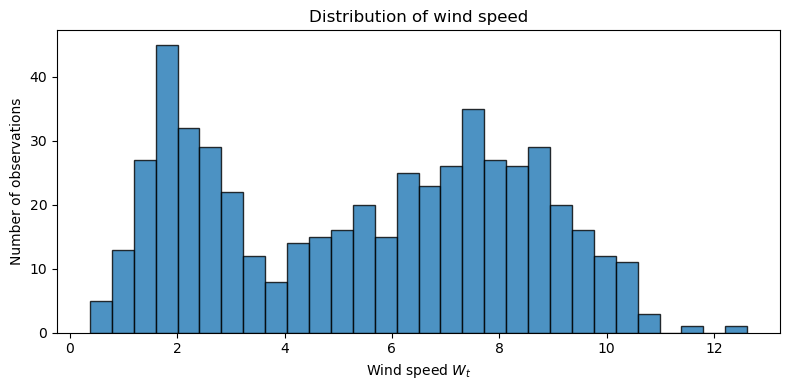

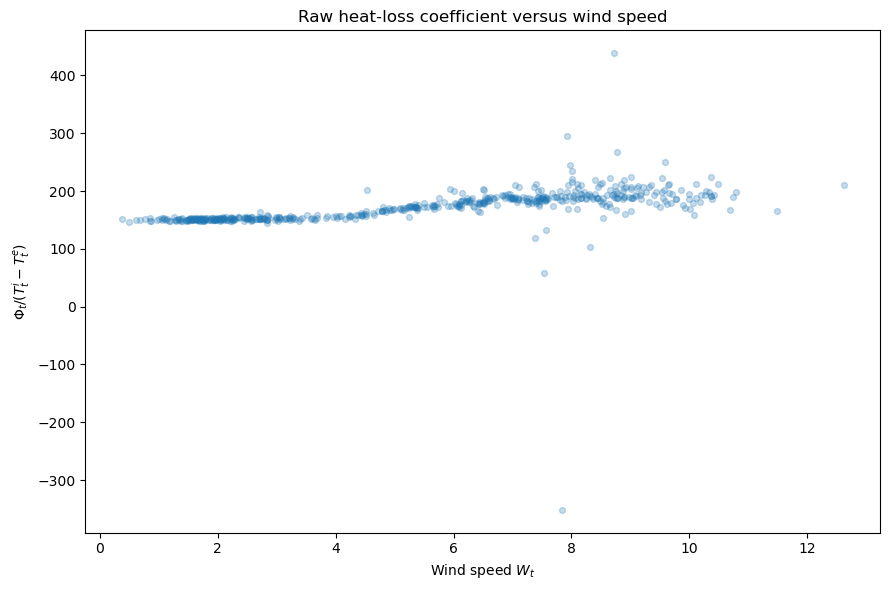

In [6]:
# Distribution of wind speed
plt.figure(figsize=(8, 4))
plt.hist(wind, bins=30, edgecolor="black", alpha=0.8)
plt.xlabel("Wind speed $W_t$")
plt.ylabel("Number of observations")
plt.title("Distribution of wind speed")
plt.tight_layout()
plt.show()

# Raw heat-loss coefficient against wind speed
plt.figure(figsize=(9, 6))
plt.scatter(
    wind,
    ua_raw,
    alpha=0.25,
    s=18
)
plt.xlabel("Wind speed $W_t$")
plt.ylabel(r"$\Phi_t/(T_t^i-T_t^e)$")
plt.title("Raw heat-loss coefficient versus wind speed")
plt.tight_layout()
plt.show()


We observe that there are very few (sparse data) observations at high wind speed (> 11)

## Defining the Epanechnikov kernel


In [7]:
def epanechnikov(u):
    """
    Epanechnikov kernel

        K(u) = 3/4 * (1 - u^2),  |u| <= 1
               0,                otherwise
    """
    u = np.asarray(u)

    return np.where(
        np.abs(u) <= 1,
        0.75 * (1 - u**2),
        0.0
    )


## Local quadratic regression


In [ ]:
def estimate_Ua_local(
    wind,
    ua_raw,
    wind_grid,
    bandwidth,
    degree=2
):
    """
    Estimate Ua(W) using locally weighted polynomial regression
    with an Epanechnikov kernel.


        Ua(W) ≈ beta_0
              + beta_1 (W - w0)
              + beta_2 (W - w0)^2

    Because the polynomial is centered at w0,

        Ua_hat(w0) = beta_0.

    """
    wind = np.asarray(wind)
    ua_raw = np.asarray(ua_raw)

    ua_hat = np.full(len(wind_grid), np.nan)

    for j, w0 in enumerate(wind_grid):

        # Center wind speed around the current fitting point
        z = wind - w0

        # Epanechnikov weights
        weights = epanechnikov(z / bandwidth)

        # Only observations inside the bandwidth contribute
        mask = weights > 0

        # Need at least degree + 1 points to fit the polynomial
        if np.sum(mask) < degree + 1:
            continue

        z_local = z[mask]
        y_local = ua_raw[mask]
        w_local = weights[mask]

        # Local polynomial design matrix
        X = np.column_stack([
            z_local**k
            for k in range(degree + 1)
        ])

        # Weighted least squares
        sqrt_w = np.sqrt(w_local)

        Xw = X * sqrt_w[:, None]
        yw = y_local * sqrt_w

        beta, *_ = np.linalg.lstsq(
            Xw,
            yw,
            rcond=None
        )

        # At w = w0, z = 0, so the estimate is beta_0
        ua_hat[j] = beta[0]

    return ua_hat


## Fitting different bandwidths


In [ ]:
wind_grid = np.linspace(
    wind.min(),
    wind.max(),
    300
)

# Choise of bandwidths
bandwidths = [0.5, 0.75, 1.0, 1.25, 1.5]

estimates = {}

for h in bandwidths:
    estimates[h] = estimate_Ua_local(
        wind=wind,
        ua_raw=ua_raw,
        wind_grid=wind_grid,
        bandwidth=h,
        degree=2
    )


## Plotting all bandwidths together with the data


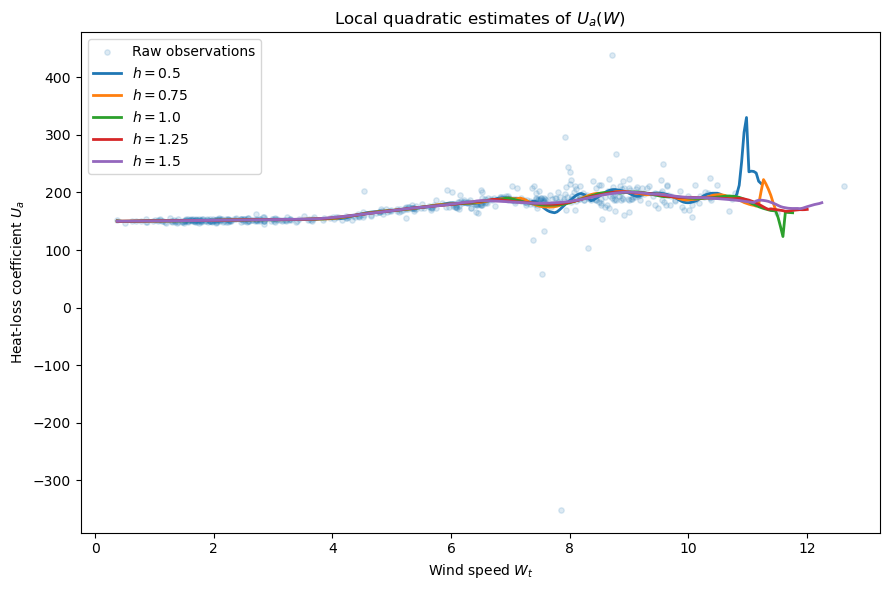

In [10]:
plt.figure(figsize=(9, 6))

plt.scatter(
    wind,
    ua_raw,
    alpha=0.15,
    s=15,
    label="Raw observations"
)

for h in bandwidths:
    plt.plot(
        wind_grid,
        estimates[h],
        linewidth=2.0,
        label=fr"$h={h}$"
    )

plt.xlabel("Wind speed $W_t$")
plt.ylabel(r"Heat-loss coefficient $U_a$")
plt.title("Local quadratic estimates of $U_a(W)$")
plt.legend()
plt.tight_layout()
plt.show()


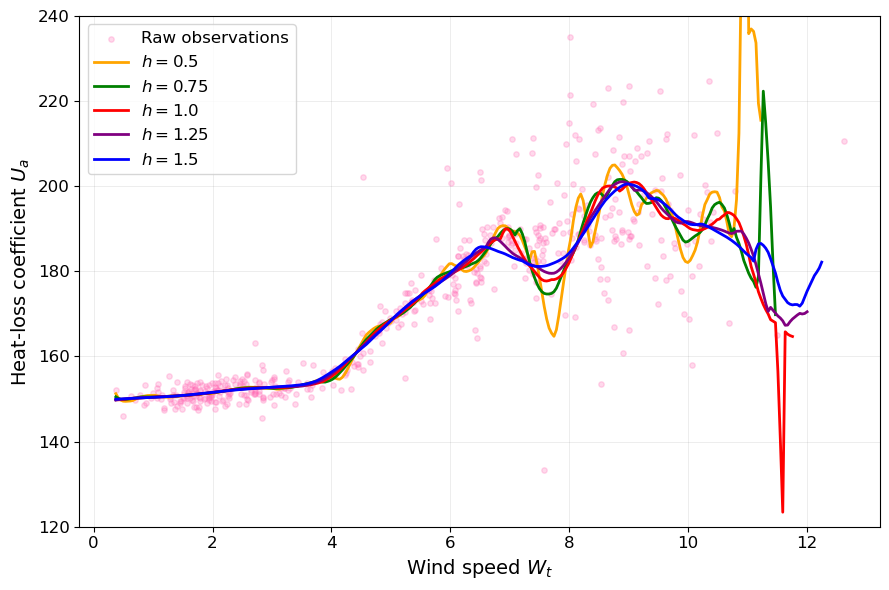

In [40]:
plt.figure(figsize=(9, 6))

plt.scatter(
    wind,
    ua_raw,
    color='hotpink',
    alpha=0.25,
    s=15,
    label="Raw observations"
)

colors = ['orange', 'green', 'red', 'purple', 'blue']

for h, color in zip(bandwidths, colors):
    plt.plot(
        wind_grid,
        estimates[h],
        color=color,
        linewidth=2,
        label=fr"$h={h}$"
    )

plt.legend()

plt.ylim(120,240)
plt.xlabel("Wind speed $W_t$", fontsize = 14)
plt.ylabel(r"Heat-loss coefficient $U_a$", fontsize = 14)
#plt.title("Estimated heat loss coefficients plot ($U_a(W)$)")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.gca().set_axisbelow(True)
plt.grid(True, color='gray', alpha=0.2, linewidth=0.5)
plt.show()

## Looking closer on the dense-data region


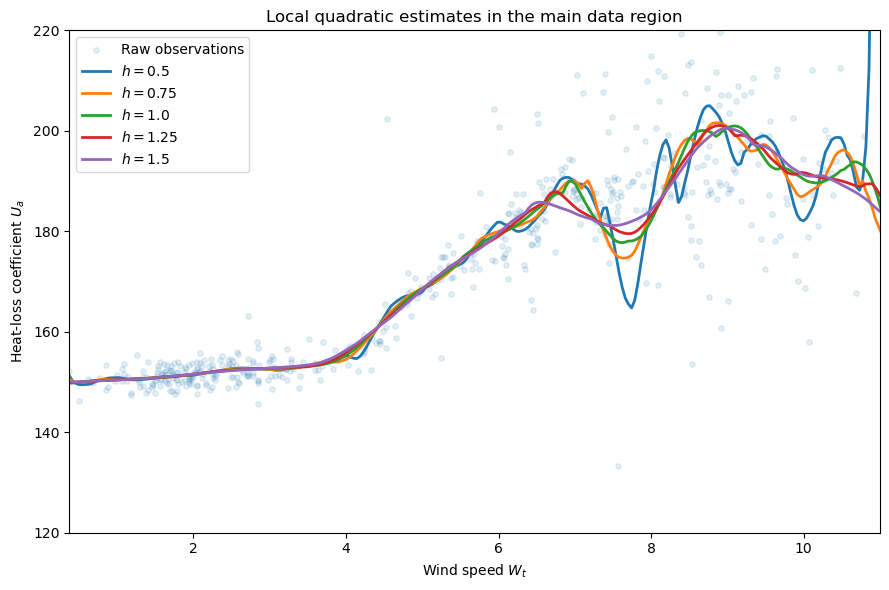

In [12]:
plt.figure(figsize=(9, 6))

plt.scatter(
    wind,
    ua_raw,
    alpha=0.12,
    s=15,
    label="Raw observations"
)

for h in bandwidths:
    plt.plot(
        wind_grid,
        estimates[h],
        linewidth=2.0,
        label=fr"$h={h}$"
    )

plt.ylim(120,220)
plt.xlim(wind.min(), 11)
plt.xlabel("Wind speed $W_t$")
plt.ylabel(r"Heat-loss coefficient $U_a$")
plt.title("Local quadratic estimates in the main data region")
plt.legend()
plt.tight_layout()
plt.show()


## Some simple diagnostics for sparse high-wind observations


In [13]:
for threshold in [9, 10, 11]:
    count = np.sum(wind > threshold)
    print(f"Observations with W > {threshold}: {count}")


Observations with W > 9: 63
Observations with W > 10: 21
Observations with W > 11: 2
